<a href="https://colab.research.google.com/github/Preetham-sai-1/Machine-Learning/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [26]:
data=pd.read_csv('/content/sample_data/SAP-4000.csv')
print(data.head())

   Gender  HoursStudied/Week Tutoring Region  Attendance(%) Parent Education  \
0    Male                5.5       No  Urban           72.7         Tertiary   
1  Female                6.8       No  Urban           62.0          Primary   
2  Female                9.7       No  Rural           95.0        Secondary   
3    Male               13.3      Yes  Rural           52.9              NaN   
4  Female                8.9       No  Urban           50.8              NaN   

   Exam_Score  
0        43.5  
1        51.7  
2        70.1  
3        79.5  
4        52.2  


In [27]:
print(data.isnull().sum())
data["Parent Education"]=data["Parent Education"].fillna("unknown")

Gender                 0
HoursStudied/Week      0
Tutoring               0
Region                 0
Attendance(%)          0
Parent Education     422
Exam_Score             0
dtype: int64


In [28]:
encoder=LabelEncoder()
data["Gender"]=encoder.fit_transform(data["Gender"])
data["Parent Education"]=encoder.fit_transform(data["Parent Education"])
data["Tutoring"]=encoder.fit_transform(data["Tutoring"])
data["Region"]=encoder.fit_transform(data["Region"])
print(data.head())

   Gender  HoursStudied/Week  Tutoring  Region  Attendance(%)  \
0       1                5.5         0       1           72.7   
1       0                6.8         0       1           62.0   
2       0                9.7         0       0           95.0   
3       1               13.3         1       0           52.9   
4       0                8.9         0       1           50.8   

   Parent Education  Exam_Score  
0                 2        43.5  
1                 0        51.7  
2                 1        70.1  
3                 3        79.5  
4                 3        52.2  


In [29]:
X=data.drop("Exam_Score", axis=1)
y=data["Exam_Score"]

In [30]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.3, random_state=42)

In [31]:
model=LinearRegression()
score=cross_val_score(model, X_train, y_train, cv=5)
print(score)
print("Mean Accuracy", score.mean())
model.fit(X_train, y_train)

[0.90293626 0.88800681 0.89745749 0.90379893 0.9006184 ]
Mean Accuracy 0.8985635765179787


LinearRegression()

In [22]:
predict=model.predict(X_test)

In [23]:
print("MSE", mean_squared_error(y_test, predict))
print("R^2", r2_score(y_test, predict))

MSE 27.688632384391823
R^2 0.9056769395564219


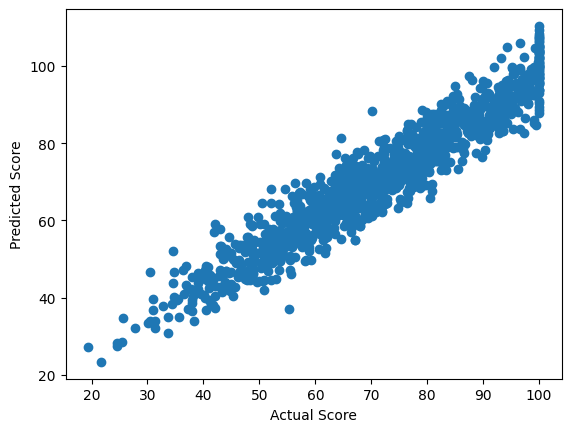

In [34]:
plt.scatter(y_test, predict)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.show()

In [35]:
Student=[[1, 8.5, 1, 1, 90, 2]]
score=model.predict(Student)
score

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([80.65124847])